In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Flatten, Dropout, TimeDistributed
from tensorflow.keras.layers import Reshape
from tensorflow.keras.optimizers import Adam


In [18]:
# Path to your dataset
data_dir = "D:\PROJECTS\isl\Indian"

img_height, img_width = 64, 64
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3
)

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\pavan\AppData\Local\Temp\ipykernel_19436\1482503662.py:2: SyntaxWarning: invalid escape sequence '\P'
  data_dir = "D:\PROJECTS\isl\Indian"


Found 29923 images belonging to 35 classes.
Found 12822 images belonging to 35 classes.


In [19]:
sequence_length = img_height  # treat each row as a timestep
feature_size = img_width * 3  # each row has img_width pixels × 3 channels

model = Sequential([
    Reshape((sequence_length, feature_size), input_shape=(img_height, img_width, 3)),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


c:\Users\pavan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 64, 192)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,195 (860.14 KB)

 Trainable params: 220,195 (860.14 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)


c:\Users\pavan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
936/936 ━━━━━━━━━━━━━━━━━━━━ 432s 456ms/step - accuracy: 0.7218 - loss: 1.0818 - val_accuracy: 0.9644 - val_loss: 0.1268
Epoch 2/5
936/936 ━━━━━━━━━━━━━━━━━━━━ 131s 124ms/step - accuracy: 0.9976 - loss: 0.0099 - val_accuracy: 0.9204 - val_loss: 0.3274
Epoch 3/5
936/936 ━━━━━━━━━━━━━━━━━━━━ 100s 107ms/step - accuracy: 0.9429 - loss: 0.1876 - val_accuracy: 0.9825 - val_loss: 0.1224
Epoch 4/5
936/936 ━━━━━━━━━━━━━━━━━━━━ 100s 107ms/step - accuracy: 0.9954 - loss: 0.0154 - val_accuracy: 0.9835 - val_loss: 0.0909
Epoch 5/5
936/936 ━━━━━━━━━━━━━━━━━━━━ 99s 106ms/step - accuracy: 0.9975 - loss: 0.0068 - val_accuracy: 0.9825 - val_loss: 0.0950


In [22]:
model.save("isl_rnn_model.keras")  # Saves in the 'SavedModel' directory format

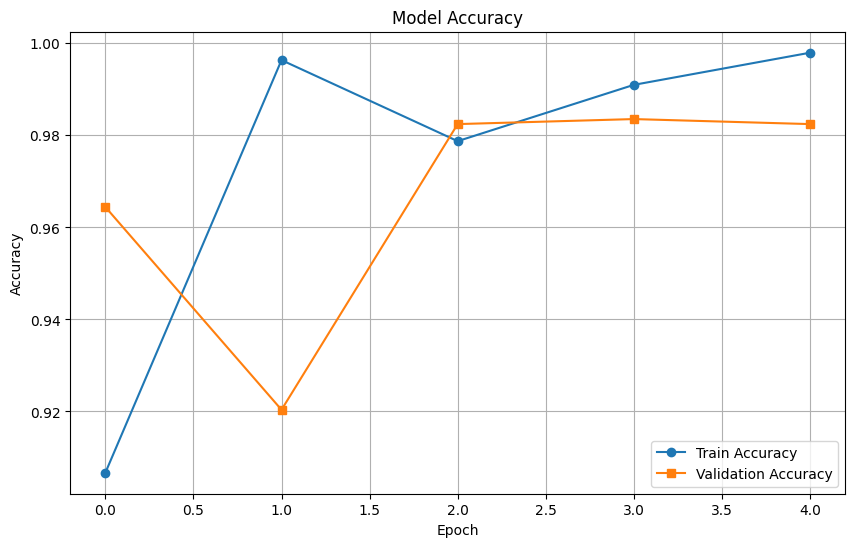


Final Train Accuracy: 99.80%
Final Validation (Test) Accuracy: 98.25%


In [23]:
# Plot training & validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print final accuracy values
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"\nFinal Train Accuracy: {train_acc:.2%}")
print(f"Final Validation (Test) Accuracy: {val_acc:.2%}")


In [25]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import numpy as np

# Step 1: Reset generator and get predictions
val_generator.reset()
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Step 2: Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"✅ Overall Accuracy: {accuracy:.2%}")

# Step 3: Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Step 4: ROC-AUC Score (optional for multi-class)
try:
    y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=len(class_labels))
    auc_score = roc_auc_score(y_true_onehot, y_pred_probs, average='macro', multi_class='ovr')
    print(f"\n🔍 ROC-AUC Score (macro-average): {auc_score:.4f}")
except:
    print("\n⚠️ ROC-AUC calculation failed (likely due to small number of classes or missing labels)")


401/401 ━━━━━━━━━━━━━━━━━━━━ 40s 101ms/step
✅ Overall Accuracy: 98.25%

📋 Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       360
           2       1.00      1.00      1.00       360
           3       1.00      1.00      1.00       360
           4       1.00      1.00      1.00       360
           5       1.00      1.00      1.00       360
           6       1.00      1.00      1.00       360
           7       1.00      1.00      1.00       360
           8       1.00      1.00      1.00       360
           9       1.00      1.00      1.00       360
           A       1.00      1.00      1.00       360
           B       1.00      1.00      1.00       360
           C       0.67      0.99      0.80       434
           D       1.00      1.00      1.00       360
           E       1.00      1.00      1.00       360
           F       1.00      1.00      1.00       360
           G       1.00      1.00     

In [31]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Step 1: Load your pre-trained model (if not already loaded)
model = load_model('isl_rnn_model.keras')

# Step 2: Prepare the input (example with image input)
img_path = 'Indian/E/13.jpg'  # Path to the input image
img = image.load_img(img_path, target_size=(64, 64))  # Resize to the required input size for your model
img_array = image.img_to_array(img)  # Convert image to array
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension (model expects a batch of inputs)

# Normalize the image if needed
img_array = img_array / 255.0  # Example for normalization

# Step 3: Predict the class probabilities
y_pred_probs = model.predict(img_array)  # For image classification, predict probabilities

# Step 4: Get the predicted class (if classification model)
y_pred = np.argmax(y_pred_probs, axis=1)  # Get the class with the highest probability

# Check the predicted class and the corresponding probability
print(f"Raw prediction probabilities: {y_pred_probs}")
print(f"Predicted class index: {y_pred}")

# Step 5: Define class labels (ensure it matches the number of classes in the model)
class_labels = [
    'class_0', 'class_1', 'class_2', 'class_3', 'class_4', 'class_5', 'class_6', 'class_7', 'class_8', 'class_9', 
    'class_10', 'class_11', 'class_12', 'class_13', 'class_14', 'class_15', 'class_16', 'class_17', 'class_18', 'class_19',
    'class_20', 'class_21', 'class_22', 'class_23', 'class_24', 'class_25', 'class_26', 'class_27', 'class_28', 'class_29', 
    'class_30', 'class_31', 'class_32', 'class_33'  # Adjusted for 34 classes
]

# Ensure the predicted class is within bounds
if 0 <= y_pred[0] < len(class_labels):
    print(f"Predicted class: {class_labels[y_pred[0]]}")
else:
    print(f"⚠️ Prediction index {y_pred[0]} is out of range. Check class labels.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step
Raw prediction probabilities: [[3.36291828e-11 3.39092331e-11 3.01455627e-12 2.47617371e-10
  2.08488879e-10 4.03161088e-10 4.37048333e-14 7.89770506e-12
  1.96779286e-08 9.75846979e-06 1.13990181e-05 9.71767644e-09
  3.62110258e-10 9.99962211e-01 2.96368952e-09 4.05735133e-11
  3.04852521e-09 4.73379998e-07 2.32451780e-10 2.72446649e-10
  2.62921640e-09 7.68457937e-07 3.44160078e-09 2.11755662e-07
  1.92831582e-08 7.68765801e-07 3.35969986e-07 2.49414767e-10
  3.76869175e-10 1.65584794e-07 1.01826846e-10 1.21994353e-05
  1.36342464e-06 3.28905542e-10 3.65349962e-07]]
Predicted class index: [13]
Predicted class: class_13


In [32]:

img_paths = ['Indian/E/521.jpg', 'Indian/X/112.jpg', 'Indian/7/142.jpg']  # List of image paths
for img_path in img_paths:
    img = image.load_img(img_path, target_size=(64,64))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0  # Normalize

    # Prediction
    y_pred_probs = model.predict(img_array)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print(f"Image: {img_path}")
    print(f"Predicted class index: {y_pred[0]}")
    print(f"Predicted class: {class_labels[y_pred[0]]}")
    print(f"Prediction probabilities: {y_pred_probs}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
Image: Indian/E/521.jpg
Predicted class index: 13
Predicted class: class_13
Prediction probabilities: [[2.46926576e-11 2.39183864e-11 1.30404856e-12 1.10626210e-10
  1.00076919e-10 1.76969786e-10 2.47658729e-14 4.36576036e-12
  1.43770214e-08 9.40212522e-06 1.16823912e-05 6.81359147e-09
  2.07392478e-10 9.99963403e-01 1.46625889e-09 2.45256072e-11
  1.87841653e-09 2.72704995e-07 1.57489674e-10 1.86544780e-10
  1.86686888e-09 5.10175823e-07 2.31488517e-09 1.05610965e-07
  1.45893946e-08 5.10730274e-07 1.32375774e-07 1.25493227e-10
  1.76344411e-10 8.55660218e-08 6.97257044e-11 1.26264240e-05
  9.17728130e-07 2.18800422e-10 3.96376095e-07]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Image: Indian/X/112.jpg
Predicted class index: 32
Predicted class: class_32
Prediction probabilities: [[4.2644936e-11 5.5544205e-11 1.0828957e-09 1.2263061e-07 8.2097190e-10
  1.1485481e-07 3.7716963e-10 1.1919791e-08 2.2176466e-10 5.3076046e-06
  4.4820513e-06 4.6970266e-07 

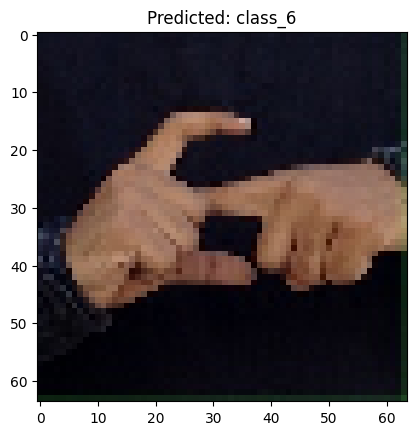

In [33]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Load and display the image with the predicted class
img_path = 'Indian/E/521.jpg'  # Replace with your image path
img = image.load_img(img_path, target_size=(64,64))  # Make sure it's the correct size for your model
plt.imshow(img)
plt.title(f"Predicted: {class_labels[y_pred[0]]}")
plt.show()


In [37]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Get actual class labels
class_labels = list(val_generator.class_indices.keys())
print(f"Number of classes: {len(class_labels)}")

# Step 1: Get predictions
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Step 2: Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.2%}")

# Step 3: Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))


Number of classes: 35
401/401 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step
Accuracy: 98.25%

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       360
           2       1.00      1.00      1.00       360
           3       1.00      1.00      1.00       360
           4       1.00      1.00      1.00       360
           5       1.00      1.00      1.00       360
           6       1.00      1.00      1.00       360
           7       1.00      1.00      1.00       360
           8       1.00      1.00      1.00       360
           9       1.00      1.00      1.00       360
           A       1.00      1.00      1.00       360
           B       1.00      1.00      1.00       360
           C       0.67      0.99      0.80       434
           D       1.00      1.00      1.00       360
           E       1.00      1.00      1.00       360
           F       1.00      1.00      1.00       360
           G       1.00      

In [38]:
import pandas as pd

# Collect predictions
predictions = []
for img_path in img_paths:  # Loop through your image paths
    img = image.load_img(img_path, target_size=(64,64))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions to match the input shape
    img_array = img_array / 255.0  # Normalize the image

    # Make prediction
    y_pred_probs = model.predict(img_array)
    y_pred = np.argmax(y_pred_probs, axis=1)
    predicted_class = class_labels[y_pred[0]]
    predicted_prob = y_pred_probs[0][y_pred[0]]

    predictions.append([img_path, predicted_class, predicted_prob])

# Save to CSV
df = pd.DataFrame(predictions, columns=["Image", "Predicted Class", "Prediction Probability"])
df.to_csv("predictions.csv", index=False)
print("Predictions saved to predictions.csv")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Predictions saved to predictions.csv
